## 1) Importar bibliotecas

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 2) Criar tensores

In [ ]:
# Tensor por padrão é invariável:
tensor1 = tf.constant([[1, 3, 7], [6, 9, 5]])

# Se quiser adicionar um tensor dinâmico, utilizar o Variable:
tensor2 = tf.Variable([[6, 4, 0, 2], [5, 5, 1, 2], [7, 8, 0, 3]])

In [7]:
print(tensor1)

tf.Tensor(
[[1 3 7]
 [6 9 5]], shape=(2, 3), dtype=int32)


In [8]:
print(tensor2)

<tf.Variable 'Variable:0' shape=(3, 4) dtype=int32, numpy=
array([[6, 4, 0, 2],
       [5, 5, 1, 2],
       [7, 8, 0, 3]], dtype=int32)>


<small>Para inferir um novo valor à um tensor <code>Variable</code>:</small>

In [ ]:
tensor2[0].assign([4, 5, 0, 1])
tensor2[1, 0].assign(2)

print(tensor2)

<tf.Variable 'Variable:0' shape=(3, 4) dtype=int32, numpy=
array([[4, 5, 0, 1],
       [2, 5, 1, 2],
       [7, 8, 0, 3]], dtype=int32)>


## 3) Operação entre tensores

### 3.1) Multiplicação com escalares:

In [12]:
tensor1 * 2

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[ 2,  6, 14],
       [12, 18, 10]], dtype=int32)>

### 3.2) Adição entre tensores:

In [14]:
tensor3 = tf.constant([[5, 0, 3], [2, 6, 7]])

tensor1 + tensor3

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[ 6,  3, 10],
       [ 8, 15, 12]], dtype=int32)>

### 3.1.1) Multiplicação:

#### 3.1.1.A) Elemento a elemento:

In [15]:
tensor1 * tensor3

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[ 5,  0, 21],
       [12, 54, 35]], dtype=int32)>

#### 3.1.1.B) Matricial

In [14]:
tensor1 @ tensor2

<tf.Tensor: shape=(2, 4), dtype=int32, numpy=
array([[ 70,  75,   3,  29],
       [116, 109,   9,  45]], dtype=int32)>

## 4) Funções de ativação:

<p>A função de ativação a ser escolhida depende do tipo de rede. Vamos conceituar brevemente três tipos de redes: MLP, CNN e RNN.</p>

<ul>
    <li><strong>MultiLayer Perceptron (MLP)</strong>: A MLP é uma rede neural com camadas totalmente conectadas. Cada neurônio em uma camada está conectado a todos os neurônios na camada seguinte. A MLP é a rede neural mais simples e comum. A MLP é usada para tarefas de classificação e regressão.</li>
    <li><strong>Convolutional Neural Network (CNN)</strong>: A CNN é uma rede neural com camadas convolucionais. A camada convolucional é uma camada especializada que aplica uma operação de convolução a seus inputs. A CNN é usada principalmente para tarefas de visão computacional, como classificação de imagens e detecção de objetos.</li>
    <li><strong>Recurrent Neural Network (RNN)</strong>: A RNN é uma rede neural com camadas recorrentes. A camada recorrente é uma camada especializada que aplica uma operação de recorrência a seus inputs. A RNN é usada principalmente para tarefas de processamento de linguagem natural, como tradução de idiomas e geração de texto.</li>
</ul>

<img src="./imagens/redes_neurais_modelos.jpeg" style="width: 50%;"/>

### 4.1) Camadas ocultas:

<p><strong>Motivação:</strong> possibilitar a não linearidade do modelo.</p>

<p>Sabendo que</p>

$z = \sum_{i=1}^{n} x_i \cdot w_i + b$

<p>Vamos adotar um tensor como sendo:</p>

In [28]:
tensor = tf.range(-10, 10, 0.5)

print(tensor)

tf.Tensor(
[-10.   -9.5  -9.   -8.5  -8.   -7.5  -7.   -6.5  -6.   -5.5  -5.   -4.5
  -4.   -3.5  -3.   -2.5  -2.   -1.5  -1.   -0.5   0.    0.5   1.    1.5
   2.    2.5   3.    3.5   4.    4.5   5.    5.5   6.    6.5   7.    7.5
   8.    8.5   9.    9.5], shape=(40,), dtype=float32)


#### 4.1.A) Sigmoid:

$z \in (-\infty, \infty)$, $\mathrm{sigmoid}(z) \in (0, 1)$

$\mathrm{sigmoid}(z) = 1 / (1 + \exp(-z))$

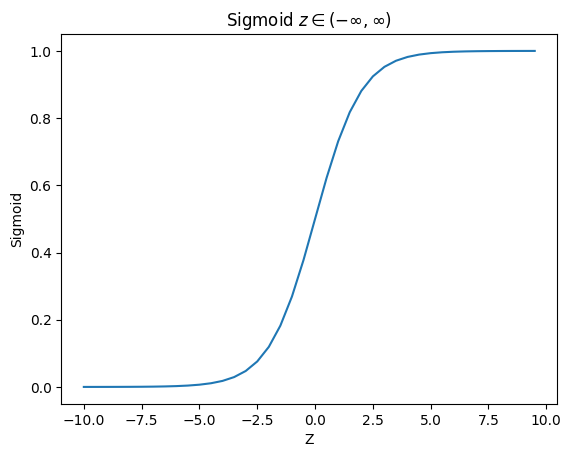

In [46]:
fig, ax = plt.subplots()

ax.plot(tensor, tf.nn.sigmoid(tensor))
ax.set_title("Sigmoid $z \in (-\infty, \infty)$")
ax.set_xlabel("Z")
ax.set_ylabel("Sigmoid")

plt.show()

#### 4.1.B) ReLU:

$z \in (-\infty, \infty)$, $\mathrm{ReLU}(z) \in (0, \infty)$

$\mathrm{relu}(z) = \mathrm{max(0, z)}$


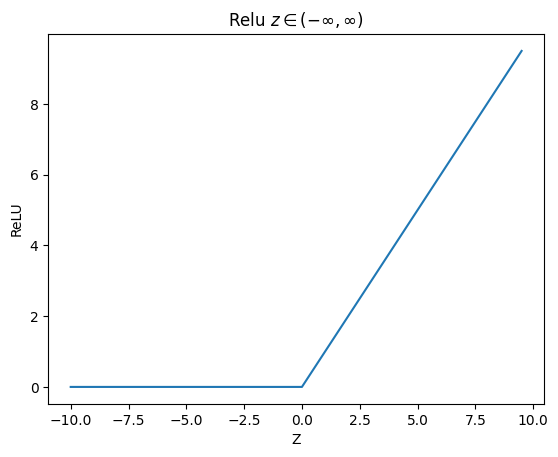

In [42]:
fig, ax = plt.subplots()

ax.plot(tensor, tf.nn.relu(tensor))
ax.set_title("Relu $z \in (-\infty, \infty)$")
ax.set_xlabel("Z")
ax.set_ylabel("ReLU")

plt.show()

#### 4.1.C) Tanh:

$z \in (-\infty, \infty)$, $\mathrm{tanh}(z) \in (-1, 1)$

$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$

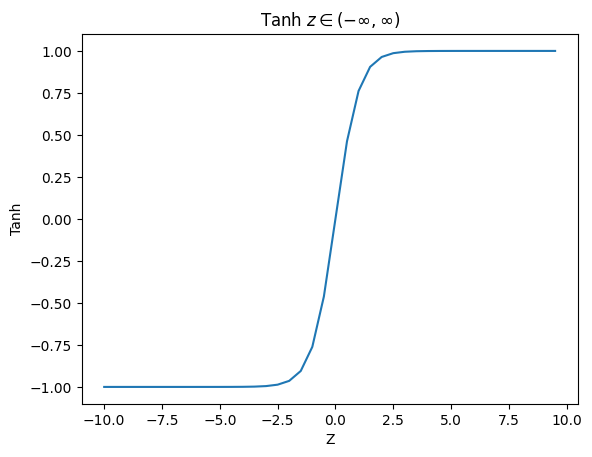

In [45]:
fig, ax = plt.subplots()

ax.plot(tensor, tf.nn.tanh(tensor))
ax.set_title("Tanh $z \in (-\infty, \infty)$")
ax.set_xlabel("Z")
ax.set_ylabel("Tanh")

plt.show()

### 4.2) Camada de saída:

<p><strong>Motivação:</strong> garantir a interpretação do resultado do modelo.</p>

<img src="./imagens/redes_neurais_saida.jpeg" style="width: 50%;"/>

#### 4.2.A) Linear:

$z \in (-\infty, \infty)$, $\mathrm{prediction}(z) \in (-\infty, \infty)$

$\mathrm{prediction}(z) = \sum_{i=1}^{n} z_i \cdot w_i + b$

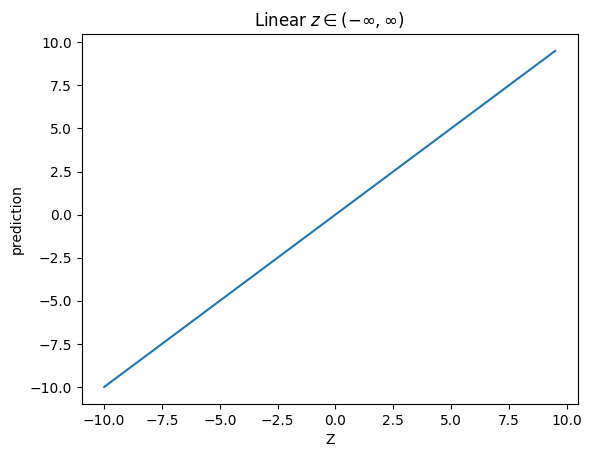

In [51]:
fig, ax = plt.subplots()

ax.plot(tensor, tensor)
ax.set_title("Linear $z \in (-\infty, \infty)$")
ax.set_xlabel("Z")
ax.set_ylabel("prediction")

plt.show()

#### 4.2.B) Softmax:

<p><strong>Motivação</strong>: atribuir a cada possibilidade de output uma probabilidade cujo somatório é 1.</p>

$z \in (-\infty, \infty)$, $\mathrm{prediction}(z) \in (-\infty, \infty)$

$ \mathrm{prediction(z)} = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} $


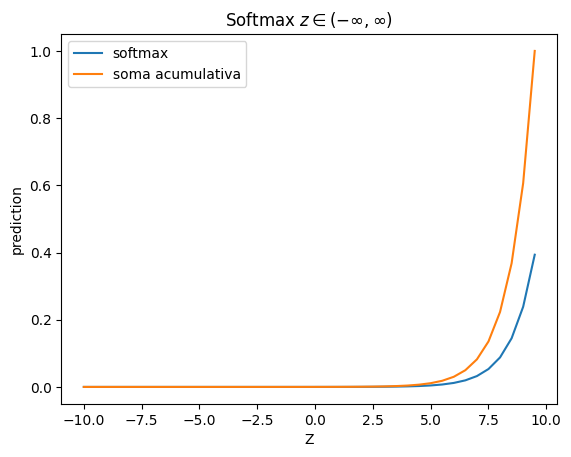

In [54]:
fig, ax = plt.subplots()

ax.plot(tensor, tf.nn.softmax(tensor), label="softmax")
ax.plot(tensor, tf.cumsum(tf.nn.softmax(tensor)), label="soma acumulativa")
ax.set_title("Softmax $z \in (-\infty, \infty)$")
ax.set_xlabel("Z")
ax.set_ylabel("prediction")

plt.legend()
plt.show()

#### 4.1.C) Sigmoid:

<p><strong>Motivação</strong>: não é exclusivo, pois serve para encontrar talvez até mais de uma característica. Assim, a soma dos resultados pode ser maior que um quando duas ou mais features sobressaírem mais.</p>

$z \in (-\infty, \infty)$, $\mathrm{sigmoid}(z) \in (0, 1)$

$\mathrm{prediction}(z) = 1 / (1 + \exp(-z))$

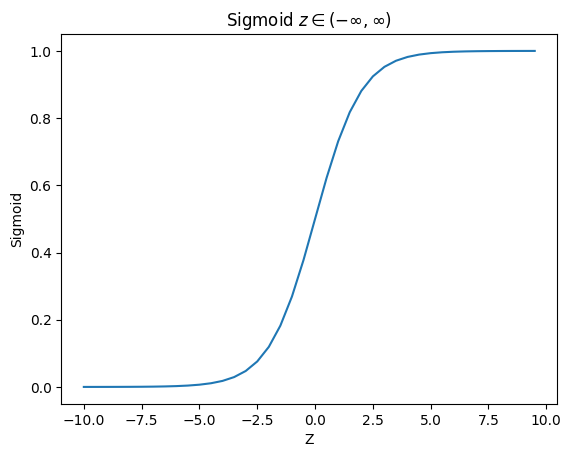

In [ ]:
fig, ax = plt.subplots()

ax.plot(tensor, tf.nn.sigmoid(tensor))
ax.set_title("Sigmoid $z \in (-\infty, \infty)$")
ax.set_xlabel("Z")
ax.set_ylabel("Prediction")

plt.show()